In [1]:
import numpy as np, curvedsky as cs, plottools as pl, healpy as hp, local
from matplotlib.pyplot import *
import warnings
warnings.filterwarnings("ignore")

In [2]:
freq = 100
freqn = {100: 0, 143: 1, 217: 2, 353: 3}

In [3]:
MptsrI = hp.fitsfunc.read_map('data/mask/HFI_Mask_PointSrc_2048_R2.00.fits',hdu=1,field=freqn[freq]) #100-353
MptsrP = hp.fitsfunc.read_map('data/mask/HFI_Mask_PointSrc_2048_R2.00.fits',hdu=2,field=freqn[freq]) #100-353

In [4]:
Mptsr = MptsrI*MptsrP

0.9863061308860779


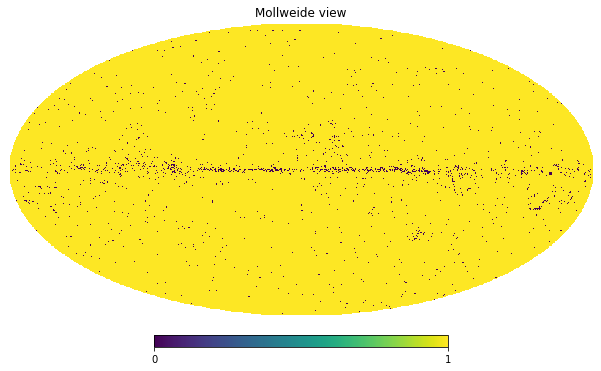

In [5]:
print(np.mean(MptsrI))
hp.mollview(MptsrI)

0.9996041854222616


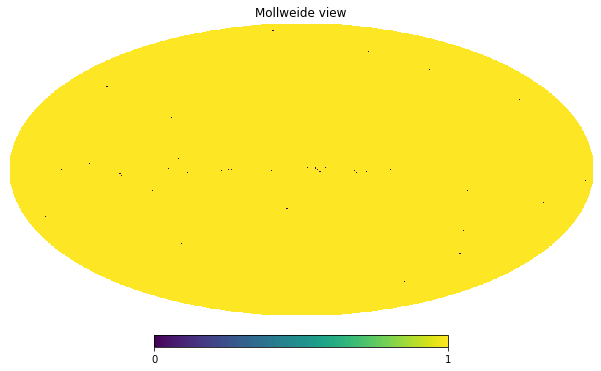

In [6]:
print(np.mean(MptsrP))
hp.mollview(MptsrP)

In [7]:
Q1 = hp.read_map('/project/projectdirs/cmb/data/planck2018/pr3/frequencymaps/HFI_SkyMap_'+str(freq)+'_2048_R3.01_halfmission-1.fits',field=1)
Q2 = hp.read_map('/project/projectdirs/cmb/data/planck2018/pr3/frequencymaps/HFI_SkyMap_'+str(freq)+'_2048_R3.01_halfmission-2.fits',field=1)

In [8]:
Mpix1 = Q1.copy()
Mpix1[Mpix1>-1e30] = 1.
Mpix1[Mpix1!=1] = 0.

In [9]:
Mpix2 = Q2.copy()
Mpix2[Mpix2>-1e30] = 1.
Mpix2[Mpix2!=1] = 0.

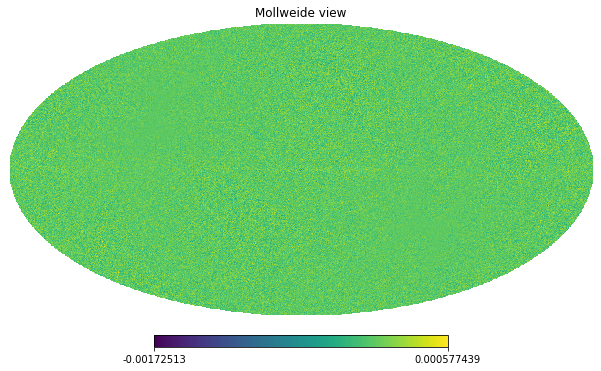

In [10]:
hp.mollview(Mpix1*Q1)

In [11]:
print(np.min(Mpix1*Q1),np.min(Mpix2*Q2),np.max(Mpix1*Q1),np.max(Mpix2*Q2))

-0.00721454992890358 -0.008253419771790504 0.001842742320150137 0.00253535364754498


0.9999497731526693


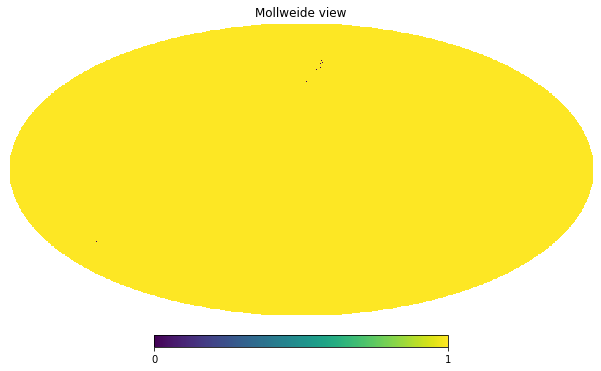

In [12]:
hp.mollview(Mpix1)
print(np.mean(Mpix1))

0.9989883701006571


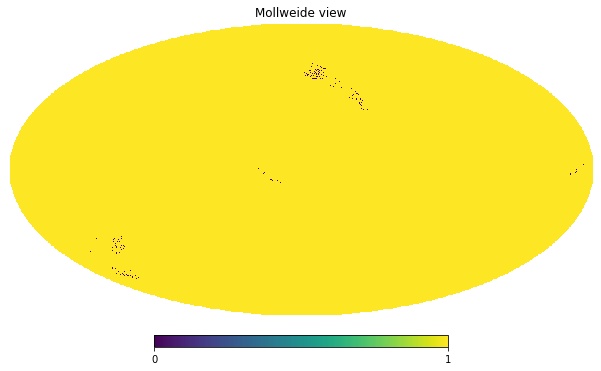

In [13]:
hp.mollview(Mpix2)
print(np.mean(Mpix2))

In [14]:
#I1 = hp.read_map('/project/projectdirs/cmb/data/planck2018/pr3/frequencymaps/HFI_SkyMap_'+str(freq)+'_2048_R3.01_halfmission-1.fits',field=0)

In [15]:
#Mpix0 = I1.copy()
#Mpix0[Mpix0>-1e30] = 1.
#Mpix0[Mpix0!=1] = 0.

In [16]:
U1 = hp.read_map('/project/projectdirs/cmb/data/planck2018/pr3/frequencymaps/HFI_SkyMap_'+str(freq)+'_2048_R3.01_halfmission-1.fits',field=2)
U2 = hp.read_map('/project/projectdirs/cmb/data/planck2018/pr3/frequencymaps/HFI_SkyMap_'+str(freq)+'_2048_R3.01_halfmission-2.fits',field=2)
print(np.min(Mpix1*U1),np.min(Mpix2*U2))

-0.0017641551094129682 -0.0020233390387147665


0.9826202392578125


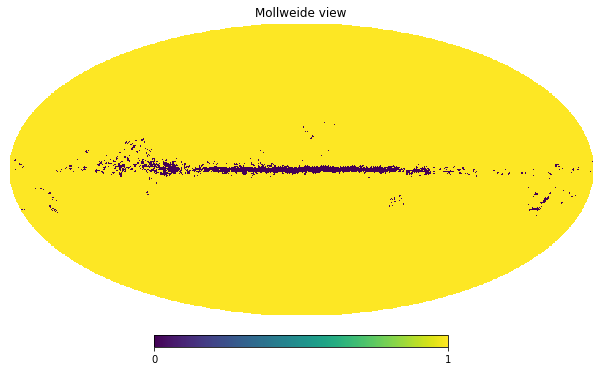

In [17]:
if freq!=143:
    McoI = hp.read_map('data/mask/HFI_BiasMap_'+str(freq)+'-CO-noiseRatio_2048_R3.00_full.fits',field=0)
    McoQ = hp.read_map('data/mask/HFI_BiasMap_'+str(freq)+'-CO-noiseRatio_2048_R3.00_full.fits',field=1)
    McoU = hp.read_map('data/mask/HFI_BiasMap_'+str(freq)+'-CO-noiseRatio_2048_R3.00_full.fits',field=2)
    McoI[McoI<-2] = 0.
    McoI[McoI!=0] = 1.
    McoQ[McoQ<-2] = 0.
    McoQ[McoQ!=0] = 1.
    McoU[McoU<-2] = 0.
    McoU[McoU!=0] = 1.
    Mco = (1.-McoQ)*(1.-McoU)*(1.-McoI)
    hp.mollview(Mco)
    print(np.mean(Mco))
else:
    Mco = 1.

In [18]:
rmask1 = Mptsr*Mpix1*Mco
rmask2 = Mptsr*Mpix2*Mco

In [19]:
print(np.mean(rmask1**2))
print(np.mean(rmask2**2))

0.973233183224996
0.9722862641016642


In [20]:
amask1 = cs.utils.apodize(2048, rmask1, 0.5)
amask2 = cs.utils.apodize(2048, rmask2, 0.5)

In [21]:
print(np.mean(amask1**2))
print(np.mean(amask2**2))

0.9236804371629189
0.9136614941259027


In [22]:
hp.fitsfunc.write_map('data/mask/PR3_HFI_'+str(freq)+'_0.5deg.fits',np.array([amask1,amask2]),overwrite=True)

In [23]:
M0 = hp.read_map('data/mask/PR3_HFI_'+str(freq)+'_0.5deg.fits',field=0)
M1 = hp.read_map('data/mask/PR3_HFI_'+str(freq)+'_0.5deg.fits',field=1)

In [24]:
print(np.mean(M0**2),np.mean(M1**2))

0.9236804371644173 0.9136614941278923


In [25]:
M0 = hp.ud_grade(M0,1024)
lmax = 1024
palm = cs.utils.hp_map2alm(1024,lmax,lmax,M0)
clmm = cs.utils.alm2cl(lmax,palm)

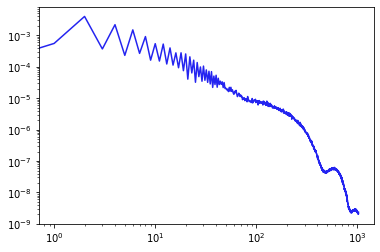

In [26]:
loglog(clmm)